# Question 1: Predicting Traditional Development Metrics (How good is the Chronic Disease Index)

### We first start with our import statements and data clean up before doing regression

*Warning: This file is independent of the others in this project because it requires significant computational resources to run.* 

In [1]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("iamsouravbanerjee/cause-of-deaths-around-the-world")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\chees\.cache\kagglehub\datasets\iamsouravbanerjee\cause-of-deaths-around-the-world\versions\3


In [2]:
# Core packages
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC

# Model selection and evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, LeaveOneOut, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            roc_auc_score, confusion_matrix, classification_report,
                            mean_squared_error, r2_score, mean_absolute_error)
# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline 
from sklearn.model_selection import cross_val_predict  

filename="cause_of_deaths.csv"
df = pd.read_csv(path+"/"+filename) #import disease dataframe

df_hdi_raw = pd.read_csv("Human Development Index - Full.csv")

#df.head()

## Cleaning up chronic_df

In [3]:
# chronic causes

chronic_causes = ["Alzheimer's Disease and Other Dementias",
                  "Parkinson's Disease",'Cardiovascular Diseases',
                  'Neoplasms','Diabetes Mellitus','Chronic Kidney Disease',
                  'Chronic Respiratory Diseases','Cirrhosis and Other Chronic Liver Diseases', 'HIV/AIDS']


# Or if any currently under chronic causes should not be there

In [4]:
chronic_df = df[['Country/Territory','Code','Year'] + chronic_causes].copy()

chronic_df['Total Chronic Deaths'] = chronic_df[chronic_causes].sum(axis=1)

chronic_df.head(3)

,Country/Territory,Code,Year,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Cardiovascular Diseases,Neoplasms,Diabetes Mellitus,Chronic Kidney Disease,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,HIV/AIDS,Total Chronic Deaths
0,Afghanistan,AFG,1990,1116,371,44899,11580,2108,3709,5945,2673,34,72435
1,Afghanistan,AFG,1991,1136,374,45492,11796,2120,3724,6050,2728,41,73461
2,Afghanistan,AFG,1992,1162,378,46557,12218,2153,3776,6223,2830,48,75345


In [5]:
# normalize the dataframe

normDf = pd.concat([chronic_df[chronic_causes].div(chronic_df[chronic_causes].sum(axis = 1), axis = 0), chronic_df[['Country/Territory', 'Code', 'Year', 'Total Chronic Deaths']]], axis=1)[['Country/Territory', 'Code', 'Year'] + chronic_causes + ['Total Chronic Deaths']]
normDf.head(2)

,Country/Territory,Code,Year,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Cardiovascular Diseases,Neoplasms,Diabetes Mellitus,Chronic Kidney Disease,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,HIV/AIDS,Total Chronic Deaths
0,Afghanistan,AFG,1990,0.015407,0.005122,0.619852,0.159867,0.029102,0.051205,0.082074,0.036902,0.000469,72435
1,Afghanistan,AFG,1991,0.015464,0.005091,0.619267,0.160575,0.028859,0.050694,0.082357,0.037135,0.000558,73461


In [6]:
normDf_mean = normDf.groupby(['Country/Territory', 'Code'])[chronic_causes + ['Total Chronic Deaths']].mean() #mean of normDf
normDf_mean.head(3)

,,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Cardiovascular Diseases,Neoplasms,Diabetes Mellitus,Chronic Kidney Disease,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,HIV/AIDS,Total Chronic Deaths
Country/Territory,Code,,,,,,,,,,
Afghanistan,AFG,0.015665,0.005004,0.602641,0.174575,0.034372,0.050301,0.079014,0.036889,0.001539,89082.966667
Albania,ALB,0.037107,0.010014,0.615455,0.234914,0.009396,0.017761,0.054609,0.020611,0.000134,14577.233333
Algeria,DZA,0.026061,0.006966,0.664508,0.144614,0.026801,0.047496,0.052858,0.028899,0.001797,107104.600000


## Cleaning up df_hdi_raw

In [7]:
pd.set_option('display.max_columns', None)

selected_columns = [
    col for col in df_hdi_raw.columns
    if any(
        phrase.lower() in col.lower()
        for phrase in [
            "Gross National Income",
            "Life Expectancy",
            "Human Development Index",
            "ISO3",
            "Country",
            "Human Development Groups"
        ]
    )
] #choosing our parameters (HDI, Life exp, human dev) 

df_selected_raw = df_hdi_raw[selected_columns]
df_hdi = df_selected_raw.drop(columns=[col for col in df_selected_raw.columns if 'male' in col.lower() or 'inequality' in col.lower() or 'Planetary pressures-adjusted' in col])

In [8]:
#melting
hdi_long = df_hdi.melt(
    id_vars=['Country'],
    var_name='Metric_Year',
    value_name='Value'
)

hdi_long['Metric'] = hdi_long['Metric_Year'].str.extract(r'^(.*) \(')
year_extracted = hdi_long['Metric_Year'].str.extract(r'\((\d{4})\)')
hdi_long['Year'] = pd.to_numeric(year_extracted[0], errors='coerce').astype('Int64')  

hdi_pivot = hdi_long.pivot_table(
    index=['Country', 'Year'],
    columns='Metric',
    values='Value'
).reset_index()

hdi_pivot.columns.name = None
hdi_pivot = hdi_pivot.rename(columns={
    'Human Development Index': 'HDI',
    'Life Expectancy at Birth': 'LifeExpectancy',
    'Gross National Income Per Capita': 'GNI_per_capita'
})

merged_df = pd.merge(
    chronic_df,
    hdi_pivot,
    how='inner',
    left_on=['Country/Territory', 'Year'],
    right_on=['Country', 'Year']
)

merged_df = merged_df.drop(columns=['Country'])
merged_df #our fully cleaned dataframe



,Country/Territory,Code,Year,Alzheimer's Disease and Other Dementias,Parkinson's Disease,Cardiovascular Diseases,Neoplasms,Diabetes Mellitus,Chronic Kidney Disease,Chronic Respiratory Diseases,Cirrhosis and Other Chronic Liver Diseases,HIV/AIDS,Total Chronic Deaths,GNI_per_capita,HDI,LifeExpectancy
0,Afghanistan,AFG,1990,1116,371,44899,11580,2108,3709,5945,2673,34,72435,2684.550019,0.273,45.9672
1,Afghanistan,AFG,1991,1136,374,45492,11796,2120,3724,6050,2728,41,73461,2276.289409,0.279,46.6631
2,Afghanistan,AFG,1992,1162,378,46557,12218,2153,3776,6223,2830,48,75345,2059.868084,0.287,47.5955
3,Afghanistan,AFG,1993,1187,384,47951,12634,2195,3862,6445,2943,56,77657,1525.533426,0.297,51.4664
4,Afghanistan,AFG,1994,1211,391,49308,12914,2231,3932,6664,3027,63,79741,1087.96189,0.292,51.4945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5515,Zimbabwe,ZWE,2015,754,215,16649,11161,3176,2108,2751,1956,29162,67932,3638.532892,0.582,59.5911
5516,Zimbabwe,ZWE,2016,767,219,16937,11465,3259,2160,2788,1962,27141,66698,3606.750671,0.588,60.3059
5517,Zimbabwe,ZWE,2017,781,223,17187,11744,3313,2196,2818,2007,24846,65115,3728.918785,0.594,60.7095
5518,Zimbabwe,ZWE,2018,795,227,17460,12038,3381,2240,2849,2030,22106,63126,3864.012419,0.602,61.4141


## The DataFrame `merge.df` has the information from all countries through all years with all chronic diseases and the metrics HDI, LifeExp, GNI.


# Question 1

#### Does the death ratio (defined below) correlate with established development metrics such as HDI, GNI per capita, and life expectancy?
The death ratio is a 9-dimensional vector representing the conditional probability of dying from a specific chronic disease given that an individual has contracted any chronic disease: P(death from disease i | contracted a chronic disease), for 9 major chronic diseases.

### Method
We will answer this question by creating regressor models using the death ratio to predict `GNI_per_capita`, `HDI`, and `LifeExpectancy` (_**we need to define these**_).

We will first start with a K Nearest Neighbors Regressor. 

Text(0.5, 1.0, 'Countries with Missing Data')

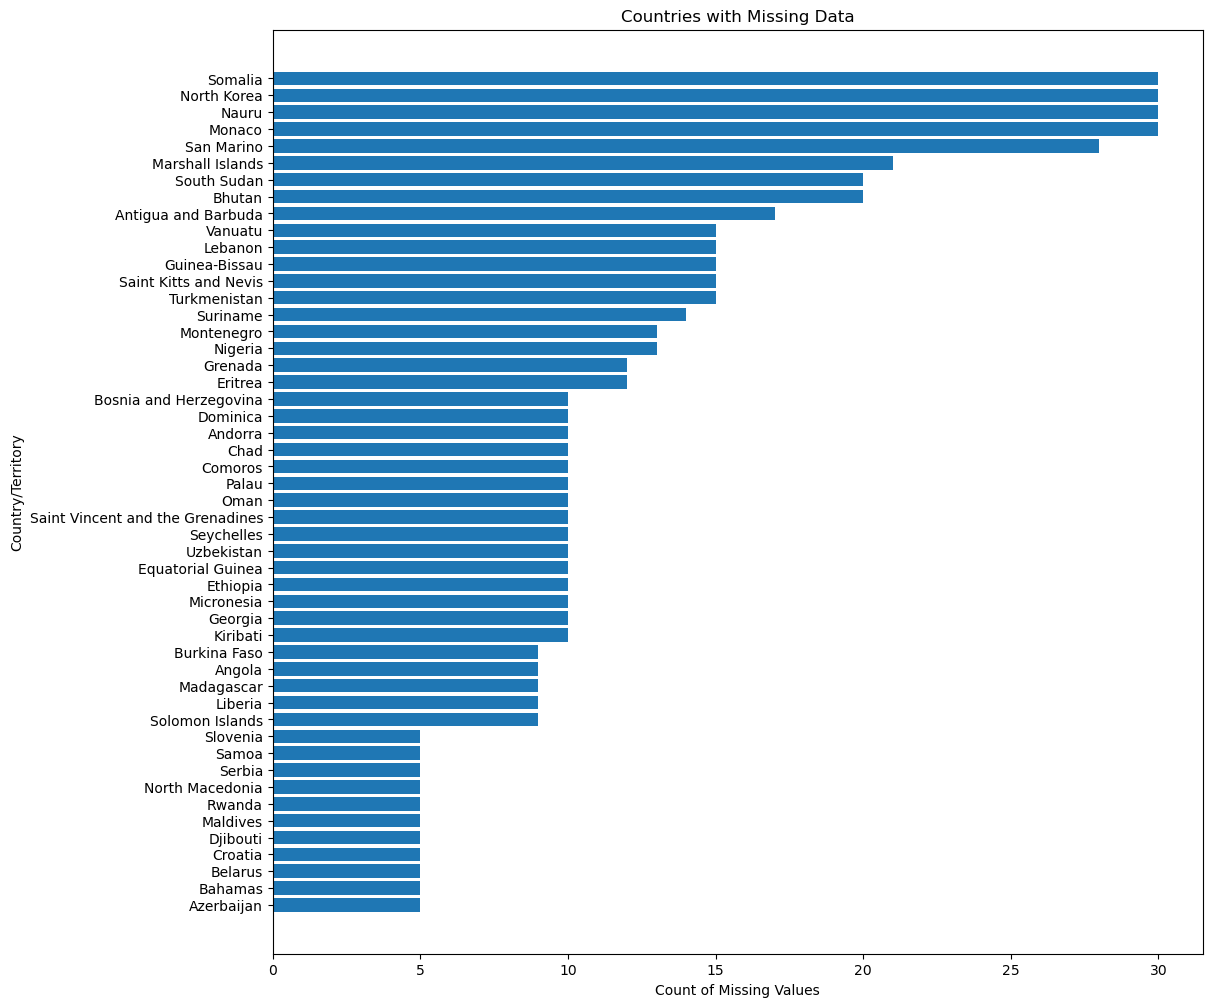

In [9]:
#before we get any further, we have some nans in our data. We will therefore drop those values. 615 rows are removed. A list of country with missing 
fig1 = plt.figure(figsize = (12,12))

# Get countries with missing values and their counts
missing_data = merged_df[merged_df.isna().any(axis=1)].groupby('Country/Territory').size().sort_values()

# Plot horizontal bar chart with both y-coordinates (countries) and x-coordinates (counts)
plt.barh(y=missing_data.index, width=missing_data.values)

plt.xlabel('Count of Missing Values')
plt.ylabel('Country/Territory')
plt.title('Countries with Missing Data')

## Remarks on Missing Data

Unfortunately, certain countries simply have some missing data for some values. This is usually because the country is ruled by a dicatator that wishes to control the narrative about their country (e.g. North Korea), is simply too remote/small to have all the data collected (e.g. Andorra, Bhutan), or is in a war (e.g. South Sudan). 

For the purposes of investigating the death ratio as a metric, we will disregard all country-year combos with even a single missing value. Dropping these rows is reasonable because the number of missing rows per country shows no clear relationship with the metrics (see below). Note, however, that rows from the same country are *not* independent of each other, since neighboring years are nearly identical. The model evaluation below accounts for this by holding out whole countries. 

Also, notice that there is no visual correlation between the number of missing rows and the metrics for each country. 

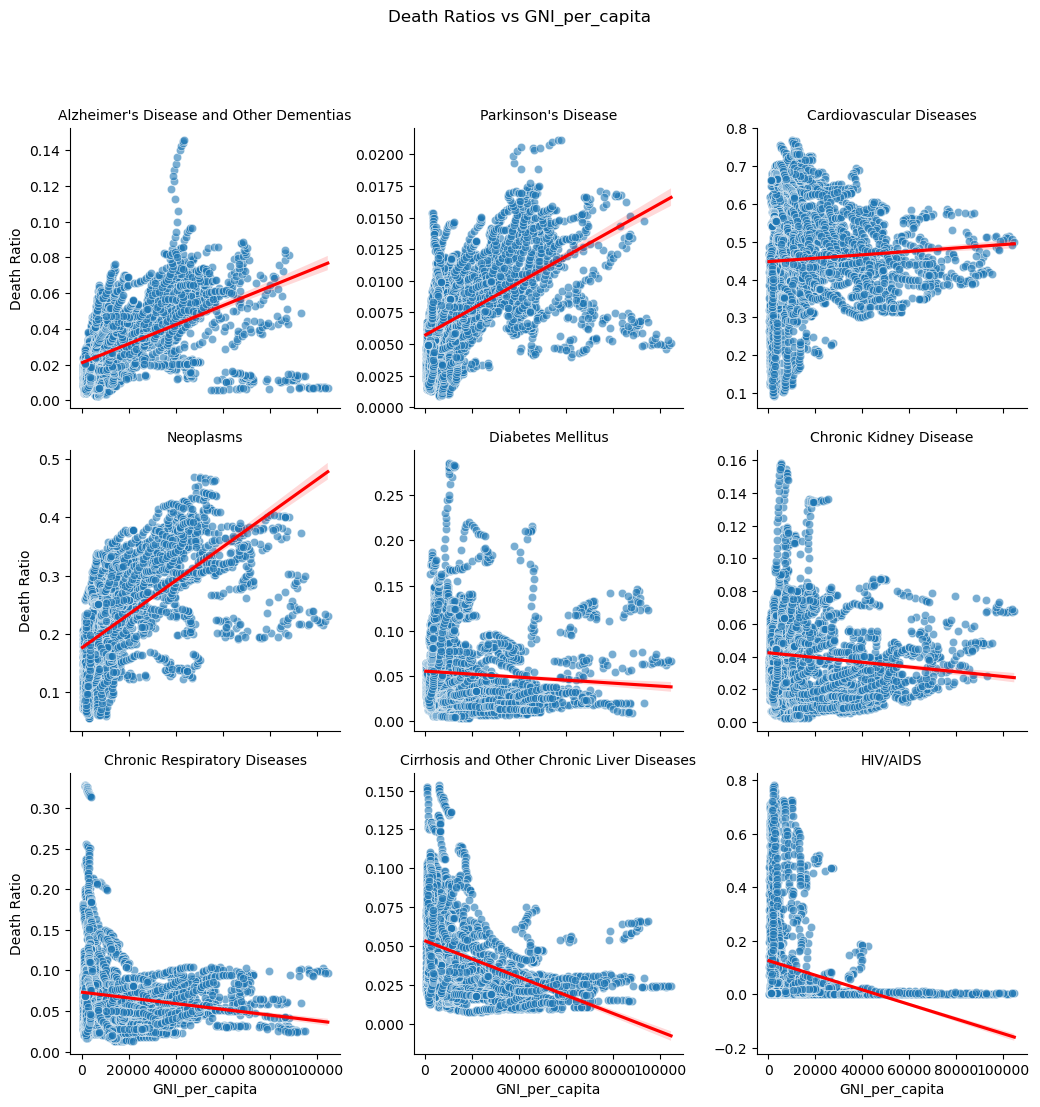

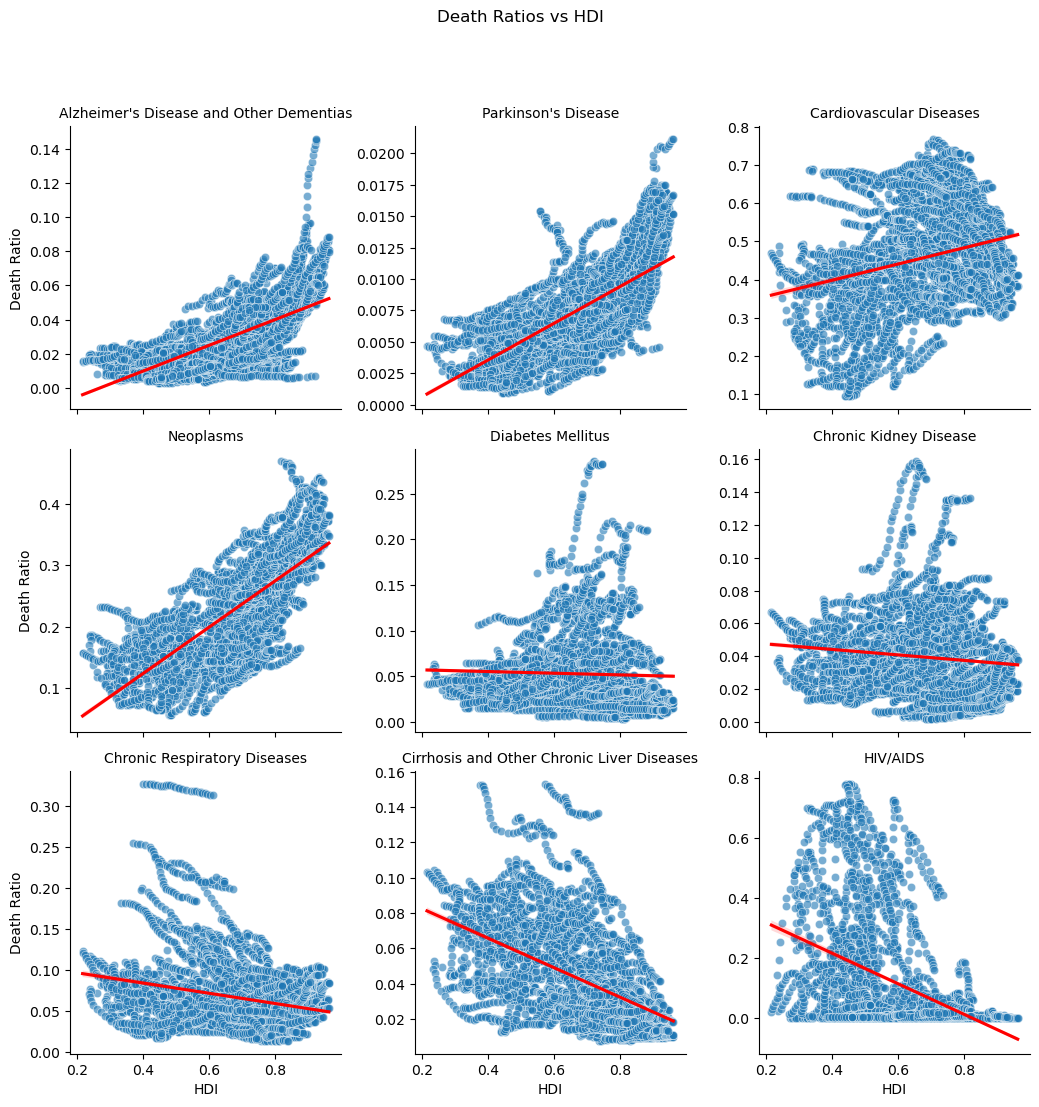

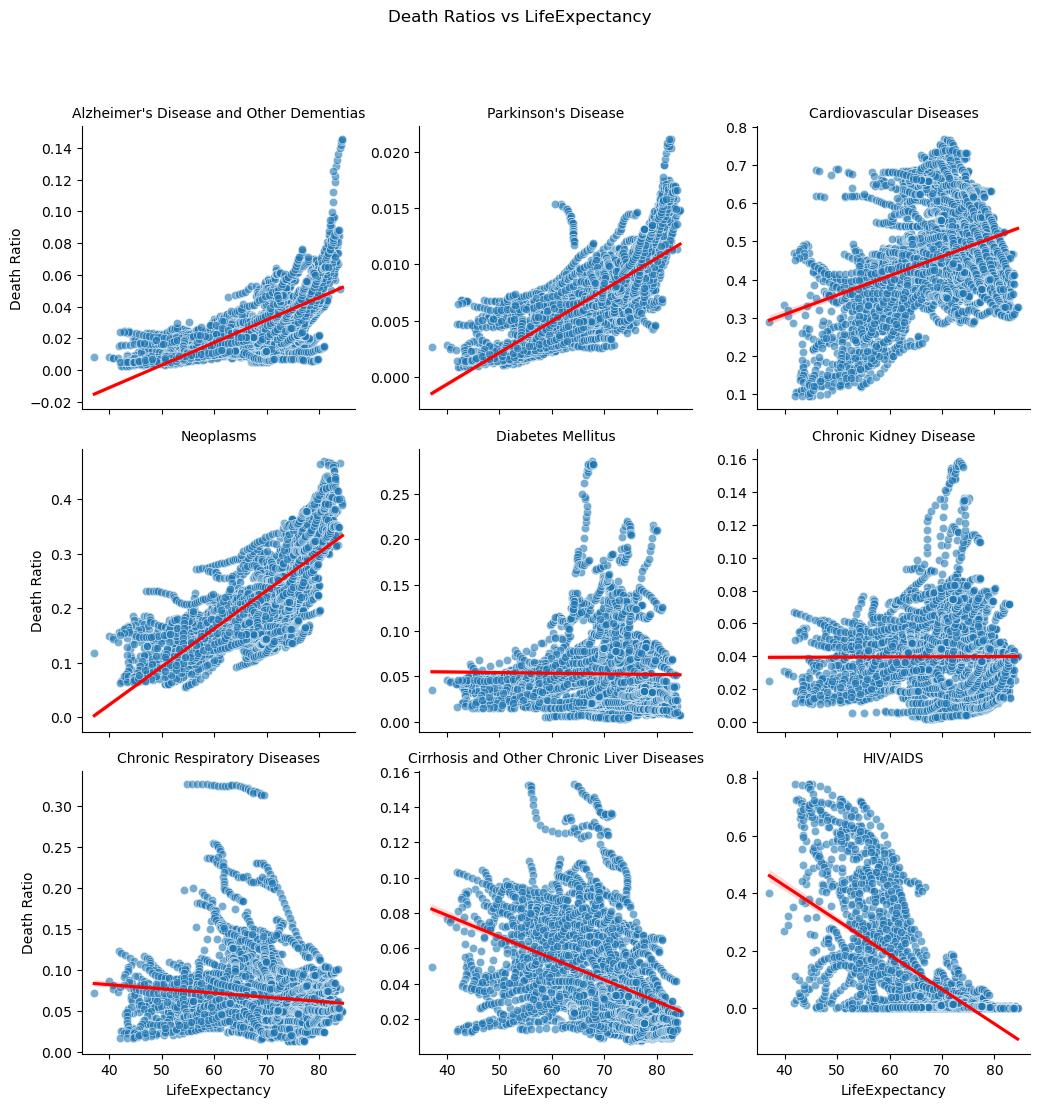

In [10]:

death_ratio = merged_df[chronic_causes].apply(pd.to_numeric, errors='coerce').divide(
    merged_df['Total Chronic Deaths'], axis=0)

plot_df = pd.concat([
    merged_df[['GNI_per_capita', 'HDI', 'LifeExpectancy']].apply(pd.to_numeric, errors='coerce'),  # Convert metrics to numeric
    death_ratio
], axis=1)

plot_df = plot_df.dropna()

# Melt df for seaborn
melted = plot_df.melt(
    id_vars=['GNI_per_capita', 'HDI', 'LifeExpectancy'],
    value_vars=chronic_causes,
    var_name='Cause',
    value_name='Death Ratio'
)
#graphing 
metrics = ['GNI_per_capita', 'HDI', 'LifeExpectancy']
for metric in metrics:
    g = sns.FacetGrid(
        melted, col='Cause', col_wrap=3, height=3.5, sharey=False
    )
    g.map_dataframe(
        sns.scatterplot, x=metric, y='Death Ratio', alpha=0.6
    )
    g.map_dataframe(
        sns.regplot, x=metric, y='Death Ratio', scatter=False, color='red'
    )
    g.set_titles("{col_name}")
    g.fig.suptitle(f"Death Ratios vs {metric}", y=1.05)
    plt.tight_layout()
    plt.show()

## Remarks: EDA

This is just for a quick visual of correlation between the individual death ratio component and the metrics. We make more remarks upon the data in the written report. For now, we will point out the it seems only a few diseases have strong monotonic correlation with any given metric.

In [11]:
#set up all the vectors to be put into the predictors
death_ratio = merged_df[chronic_causes].divide(merged_df['Total Chronic Deaths'], axis = 0) # P(death from disease i | contracted a chronic disease)
y_gni = merged_df['GNI_per_capita'] #a column with all the GNI's for each country-year pair
y_life = merged_df['LifeExpectancy'] #for life expectancy
y_hdi = merged_df['HDI'] #for HDI

## Evaluation setup: hold out whole countries

Each country appears up to 29 times (once per year), and neighboring years are nearly identical. If rows are split at random, the model is tested on years of countries it has already seen, which inflates R². So:

1. **20% of countries are held out** as a test set and never used for tuning or feature selection.
2. **Cross-validation groups by country** (`GroupKFold`), so no country is in both a training fold and a validation fold.
3. **Reported scores come from data the model was not fit on.** Earlier versions computed R² with `grid_search.predict(X)` on the same rows the final model was trained on, which is a training score.
4. **A mean-value baseline** (`DummyRegressor`) is scored on the same test countries, so the R² values have something to be compared against.

In [12]:
from sklearn.model_selection import GroupKFold
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer

# Hold out 20% of countries once, shared across all targets and all feature combos.
all_codes = merged_df['Code'].drop_duplicates()
test_codes = set(all_codes.sample(frac=0.2, random_state=42))
print(f"{len(test_codes)} test countries, {len(all_codes) - len(test_codes)} training countries")

cv = GroupKFold(n_splits=5)   # folds never split a country

37 test countries, 147 training countries


In [13]:
targets = {
    'GNI_per_capita': y_gni,
    'LifeExpectancy': y_life,
    'HDI': y_hdi
}


param_grid = {
    'scaler__with_mean': [True, False],
    'scaler__with_std': [True, False],
    'knn__n_neighbors': range(1, 500, 5),
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

In [14]:
# Define X (death ratio)
X_all = merged_df[chronic_causes].divide(merged_df['Total Chronic Deaths'], axis=0)
results = []

for name in targets:
    data = pd.concat([X_all, merged_df[[name, 'Code']]], axis=1).dropna()
    train = ~data['Code'].isin(test_codes)

    X_tr, y_tr, g_tr = data.loc[train, chronic_causes], data.loc[train, name], data.loc[train, 'Code']
    X_te, y_te = data.loc[~train, chronic_causes], data.loc[~train, name]

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor())
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,                 # grouped by country
        scoring='r2',
        n_jobs=-1
    )
    grid_search.fit(X_tr, y_tr, groups=g_tr)

    # Score on countries the model has never seen
    y_pred = grid_search.predict(X_te)
    baseline = DummyRegressor().fit(X_tr, y_tr).predict(X_te)

    results.append({
        'Target': name,
        'Best n_neighbors': grid_search.best_params_['knn__n_neighbors'],
        'Best metric': grid_search.best_params_['knn__metric'],
        'with_mean': grid_search.best_params_['scaler__with_mean'],
        'with_std': grid_search.best_params_['scaler__with_std'],
        'CV R² (train countries)': grid_search.best_score_,
        'Test R² (unseen countries)': r2_score(y_te, y_pred),
        'Test MSE': mean_squared_error(y_te, y_pred),
        'Baseline test R²': r2_score(y_te, baseline),
    })

In [15]:
pd.DataFrame(results).sort_values(by='Test R² (unseen countries)')

,Target,Best n_neighbors,Best metric,with_mean,with_std,CV R² (train countries),Test R² (unseen countries),Test MSE,Baseline test R²
0,GNI_per_capita,191,euclidean,True,True,0.416946,0.286903,3.200875e+08,-0.077356
1,LifeExpectancy,96,manhattan,True,True,0.798273,0.796620,1.656510e+01,-0.032727
2,HDI,56,manhattan,True,True,0.774544,0.800196,5.940376e-03,-0.042996


## Remarks on using an all feature KNN model.

**TODO: rewrite with the new numbers.** Report the test R² on unseen countries for each target next to the mean-value baseline. Note that R² measures how much variance the model predicts, not how much is *caused* by the death ratio. Unexpectedly, the model predicted GNI per capita very poorly. 

To discuss the GNI per capita accraucy further, we first note that HDI is a function of both life expectancy, GNI per capita, and some other metrics. As both life expectancy and HDI correlated reasonably well with the death ratio, the intuitive expectation for GNI per capita is also a reasonable correlation, but this is clearly not the case.

Looking at the precise definition of HDI, we see that it is simply the geometric mean of the standardize life expectancy, GNI per capita, and mean years of schooling, so there is really no reason for GNI per capita to predict so poorly.

## Next Steps: Feature optimization

We are left with the thought that perhaps certain chronic diseases share no correlation with our metrics to predict. Thus, we shall do some feature optimization. We will test using 2, 3, and 4 diseases to check which diseases are really the best predictors.

In doing this, we will recompute the death ratio with 2, 3, and 4 elements in the vector for continuity. Ideally, we would test with all number of diseases (1-8) but that is very computationally demanding so we limit our query. 

In [16]:
# Shared helper for the feature-subset searches below.
# Tunes on training countries only (grouped CV) and returns the CV score.
# Test countries are NOT touched here, so picking the best subset by this score is fair.
subset_param_grid = {
    'scaler__with_mean': [True, False],
    'scaler__with_std': [True, False],
    'knn__n_neighbors': range(1, 100, 5),
    'knn__metric': ['euclidean', 'manhattan', 'minkowski']
}

def subset_data(combo, target_name):
    subset_df = merged_df[list(combo) + [target_name, 'Code']].dropna()
    X = subset_df[list(combo)].div(subset_df[list(combo)].sum(axis=1), axis=0)  # renormalize to sum to 1
    y = subset_df[target_name]
    train = ~subset_df['Code'].isin(test_codes)
    return X, y, subset_df['Code'], train

def make_pipeline_for(X):
    steps = [('scaler', StandardScaler()), ('knn', KNeighborsRegressor())]
    if X.isna().any().any():
        steps.insert(0, ('imputer', SimpleImputer(strategy='mean')))
    return Pipeline(steps)

def search_combo(combo, target_name):
    X, y, groups, train = subset_data(combo, target_name)
    gs = GridSearchCV(make_pipeline_for(X), subset_param_grid, cv=cv, scoring='r2', n_jobs=-1)
    gs.fit(X[train], y[train], groups=groups[train])
    return gs

In [17]:
results = []

for target_name in targets:
    for k in [2, 3, 4]:
        for combo in combinations(chronic_causes, k):
            gs = search_combo(combo, target_name)
            results.append({
                'Target': target_name,
                'Num Features': k,
                'Features': combo,
                'Best Params': gs.best_params_,
                'CV R²': gs.best_score_,
            })

feature_opt_results = pd.DataFrame(results).sort_values(by=['Target', 'CV R²'], ascending=[True, False])
feature_opt_results

,Target,Num Features,Features,Best Params,CV R²
151,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.296158
218,GNI_per_capita,4,"(Cardiovascular Diseases, Neoplasms, Chronic R...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.283916
142,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.263455
177,GNI_per_capita,4,"(Parkinson's Disease, Cardiovascular Diseases,...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.262962
150,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.257383
...,...,...,...,...,...
356,LifeExpectancy,3,"(Diabetes Mellitus, Chronic Kidney Disease, Ch...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.069315
276,LifeExpectancy,2,"(Chronic Kidney Disease, Chronic Respiratory D...","{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.036203
273,LifeExpectancy,2,"(Diabetes Mellitus, Chronic Respiratory Diseases)","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.030449
279,LifeExpectancy,2,"(Chronic Respiratory Diseases, Cirrhosis and O...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.000398


In [18]:
best_per_target = feature_opt_results.loc[
    feature_opt_results.groupby('Target')['CV R²'].idxmax()
].reset_index(drop=True)
best_per_target

,Target,Num Features,Features,Best Params,CV R²
0,GNI_per_capita,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.296158
1,HDI,4,"(Parkinson's Disease, Cardiovascular Diseases,...","{'knn__metric': 'euclidean', 'knn__n_neighbors...",0.703770
2,LifeExpectancy,4,"(Alzheimer's Disease and Other Dementias, Card...","{'knn__metric': 'manhattan', 'knn__n_neighbors...",0.751952


## Remarks on feature optimization

Overall, feature optimization with only 4 features was a bad idea. We see that the best models have maxed out number of features. In our next test, we will go through to 9 features to check if there is an optimal number of features. 

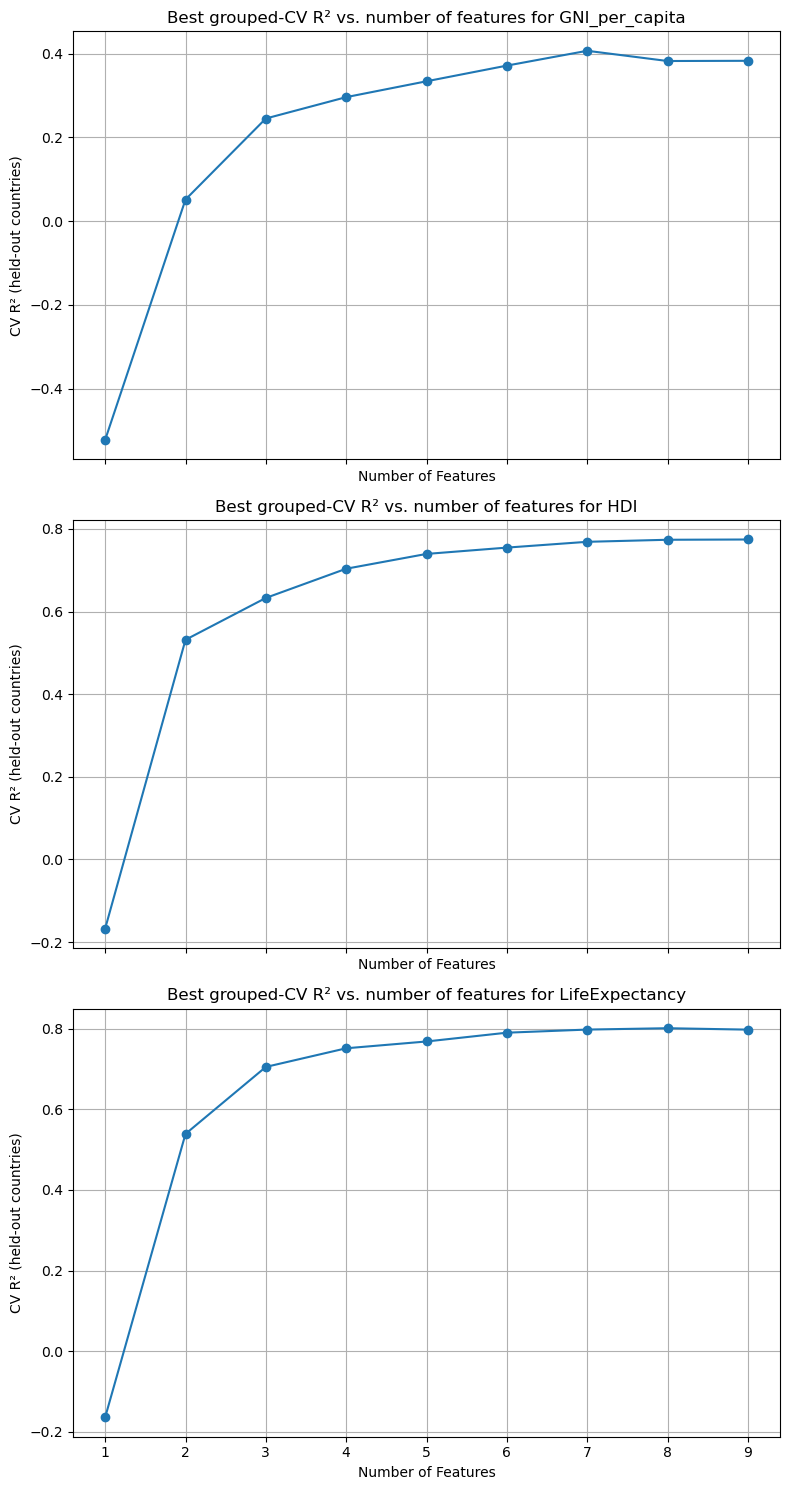

In [19]:
# You are strongly advised AGAINST running this code without at least a desktop machine.
# This code was run on an AMD 9800x3d and still took in excess of thirty minutes to run.
results = []

for target_name in targets:
    for k in range(1, 10):  # 1 through 9 features
        for combo in combinations(chronic_causes, k):
            gs = search_combo(combo, target_name)
            results.append({
                'Target': target_name,
                'Num Features': k,
                'Features': combo,
                'Best Params': gs.best_params_,
                'CV R²': gs.best_score_,
            })

feature_opt_results = pd.DataFrame(results)

best_per_k = (
    feature_opt_results
    .sort_values(by=['Target', 'Num Features', 'CV R²'], ascending=[True, True, False])
    .groupby(['Target', 'Num Features'], as_index=False)
    .first()
)

target_names = best_per_k['Target'].unique()   # don't overwrite the `targets` dict
fig, axes = plt.subplots(len(target_names), 1, figsize=(8, 5 * len(target_names)), sharex=True)
if len(target_names) == 1:
    axes = [axes]

for ax, target in zip(axes, target_names):
    subset = best_per_k[best_per_k['Target'] == target]
    ax.plot(subset['Num Features'], subset['CV R²'], marker='o', linestyle='-')
    ax.set_title(f"Best grouped-CV R² vs. number of features for {target}")
    ax.set_xlabel("Number of Features")
    ax.set_ylabel("CV R² (held-out countries)")
    ax.grid(True)

plt.tight_layout()
plt.show()

## Remark feature search

See the readme.

In [20]:
# Pick each target's best subset by CV R² (training countries only),
# then score it ONCE on the held-out test countries. These are the numbers to report.
best_models = feature_opt_results.loc[
    feature_opt_results.groupby('Target')['CV R²'].idxmax()
].reset_index(drop=True)

final = []
for _, row in best_models.iterrows():
    X, y, groups, train = subset_data(row['Features'], row['Target'])
    model = make_pipeline_for(X)
    model.set_params(**row['Best Params'])
    model.fit(X[train], y[train])
    y_pred = model.predict(X[~train])
    baseline = DummyRegressor().fit(X[train], y[train]).predict(X[~train])
    final.append({
        'Target': row['Target'],
        'Num Features': row['Num Features'],
        'Features': row['Features'],
        'CV R² (train countries)': row['CV R²'],
        'Test R² (unseen countries)': r2_score(y[~train], y_pred),
        'Test MSE': mean_squared_error(y[~train], y_pred),
        'Baseline test R²': r2_score(y[~train], baseline),
    })

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

pd.DataFrame(final)

,Target,Num Features,Features,CV R² (train countries),Test R² (unseen countries),Test MSE,Baseline test R²
0,GNI_per_capita,7,"(Alzheimer's Disease and Other Dementias, Parkinson's Disease, Cardiovascular Diseases, Chronic Kidney Disease, Chronic Respiratory Diseases, Cirrhosis and Other Chronic Liver Diseases, HIV/AIDS)",0.406850,0.129995,3.905187e+08,-0.077356
1,HDI,9,"(Alzheimer's Disease and Other Dementias, Parkinson's Disease, Cardiovascular Diseases, Neoplasms, Diabetes Mellitus, Chronic Kidney Disease, Chronic Respiratory Diseases, Cirrhosis and Other Chronic Liver Diseases, HIV/AIDS)",0.774544,0.800196,5.940376e-03,-0.042996
2,LifeExpectancy,8,"(Alzheimer's Disease and Other Dementias, Parkinson's Disease, Cardiovascular Diseases, Neoplasms, Diabetes Mellitus, Chronic Respiratory Diseases, Cirrhosis and Other Chronic Liver Diseases, HIV/AIDS)",0.801791,0.821889,1.450697e+01,-0.032727


See readme for detailed discussion.